In [1]:
#forces us to reload the libraries each time we do a function call,
#so I can update things in real time
%load_ext autoreload
%autoreload 2
#import path libraries
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from utils import psf
from utils import plotting
from utils import zernike
from tqdm import tqdm
from systematic_testing import correction


In [2]:
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300

In [3]:
N_order = 3                # 3 for 3P, 2 for 2P
lambd = 1.3e-3             # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05             # Numerical aperture
f = 7.2                    # Focal length of objective (Olympus) [mm]
grid_size = 128            # BFP resolution
L_bfp = 15.12              # BFP diameter [mm]
mag = 4                    # Magnification rate from input to objective
w_0 = 3.5                  # mm
num_apt = 1.05
L_ffp = 0.0065             # FFP size [mm]
grid_ffp = 64
grid_bfp = 64

Booth-only verification using the same optics, sample, wavefront seeds, and fixed-exposure Poisson acquisition as `correction_test.ipynb`. Each sweep shares one zero-bias image across all modes, acquires two probes per mode, and applies the combined update afterward. All measured z-planes count toward the image budget.

The diagnostic panels use the stored measurements and do not acquire additional images. The green line cancels that mode's true residual coefficient; mode coupling can move the brightness maximum away from it. The orange line is the applied update after clipping and gain. A flat or convex fit uses the best measured bias. Change `DIAGNOSTIC_TRIAL` (zero-based) and `DIAGNOSTIC_SWEEP` (one-based) to inspect another sweep. Ground truth is used only for simulation and diagnostics.


In [4]:
microscope = psf.Microscope(N_order = N_order,
                            lambd = lambd,
                            n = n,
                            num_apt = num_apt,
                            f = f,
                            mag = mag,
                            w_0 = w_0,
                            L_bfp = L_bfp,
                            grid_bfp = grid_bfp)

grid = psf.Centered_Square_Grid(L_ffp = L_ffp,
                                grid_ffp = grid_ffp,
                                z_level = 0)

xs, ys = grid.get_xy()


modes = [[-2,2],
         [2,2],
         [-3,3],
         [-1,3],
         [1,3],
         [3,3],
         [-4,4],
         [-2,4],
         [0,4],
         [2,4],
         [4,4],
         [-5,5],
         [-3, 5],
         [-1, 5],
         [1, 5],
         [3, 5],
         [5,5]]


In [5]:
NUM_TRIALS = 1
ABERRATION_RMS = 0.15
ABERRATION_SEED = 0
NOISE_SEED = 1
INITIAL_REFERENCE_SNR = 50.0
IMAGE_BUDGET = 310
OPTICAL_MODE = "vector"
CORRECTION_MODES = [mode.copy() for mode in modes]
CORRECTION_GAIN = 1.0
MAX_MODAL_UPDATE = 0.10  # Maximum SLM increment per mode per update, in waves.

BOOTH_FOCAL_POSITIONS = np.array([0.0])
BOOTH_BIAS = 0.10  # Positive probe coefficient in waves.
BOOTH_METRIC = correction.mean_brightness

z_sample_levels = np.linspace(-0.002, 0.002, 41)
mask_3D = psf.bead_img_3D(
    grid=grid, z_levels=z_sample_levels,
    xs=[0.0], ys=[0.0], zs=[0.0], bead_sizes=[0.001],
)
booth_images_per_update = len(BOOTH_FOCAL_POSITIONS) * (2 * len(CORRECTION_MODES) + 1)

DIAGNOSTIC_TRIAL = 0
DIAGNOSTIC_SWEEP = 1


In [6]:
booth_truths = []
booth_exposures = []
booth_histories = []
booth_total_updates = NUM_TRIALS * (IMAGE_BUDGET // booth_images_per_update)

with tqdm(total=booth_total_updates, desc="Booth correction") as progress:
    for trial in range(NUM_TRIALS):
        pattern_rng = np.random.default_rng(np.random.SeedSequence([ABERRATION_SEED, trial]))
        truth = zernike.RMSAberration(
            modes=modes, raw_strengths=pattern_rng.normal(0, 1, len(modes)),
            RMS_desired=ABERRATION_RMS, alpha=microscope.alpha,
        )
        booth_truths.append(truth)
        # Set exposure once from the initial zero-bias image, without spending the acquisition budget.
        _, _, _, reference_images = microscope.compute_image_3D(
            image=mask_3D, aberration=truth,
            focal_z_levels=np.array([0.0]), mode=OPTICAL_MODE,
        )
        exposure = correction.exposure_for_snr(reference_images, INITIAL_REFERENCE_SNR)
        booth_exposures.append(exposure)
        simulator = correction.SimulatedSLM(
            microscope=microscope, sample=mask_3D, truth=truth,
            correction_modes=CORRECTION_MODES, exposure=exposure,
            rng=np.random.default_rng(np.random.SeedSequence([NOISE_SEED, trial, 1])),
            optical_mode=OPTICAL_MODE,
        )
        booth_histories.append(correction.booth_feedback(
            simulator=simulator, focal_positions=BOOTH_FOCAL_POSITIONS,
            bias=BOOTH_BIAS, image_budget=IMAGE_BUDGET,
            gain=CORRECTION_GAIN, max_update=MAX_MODAL_UPDATE,
            metric=BOOTH_METRIC, on_update=lambda _: progress.update(1),
        ))

booth_image_grid = np.arange(IMAGE_BUDGET + 1)
booth_rms_by_images = np.array([
    correction.rms_at_image_counts(history, booth_image_grid)
    for history in booth_histories
])


Booth correction: 100%|██████████| 8/8 [00:22<00:00,  2.77s/it]


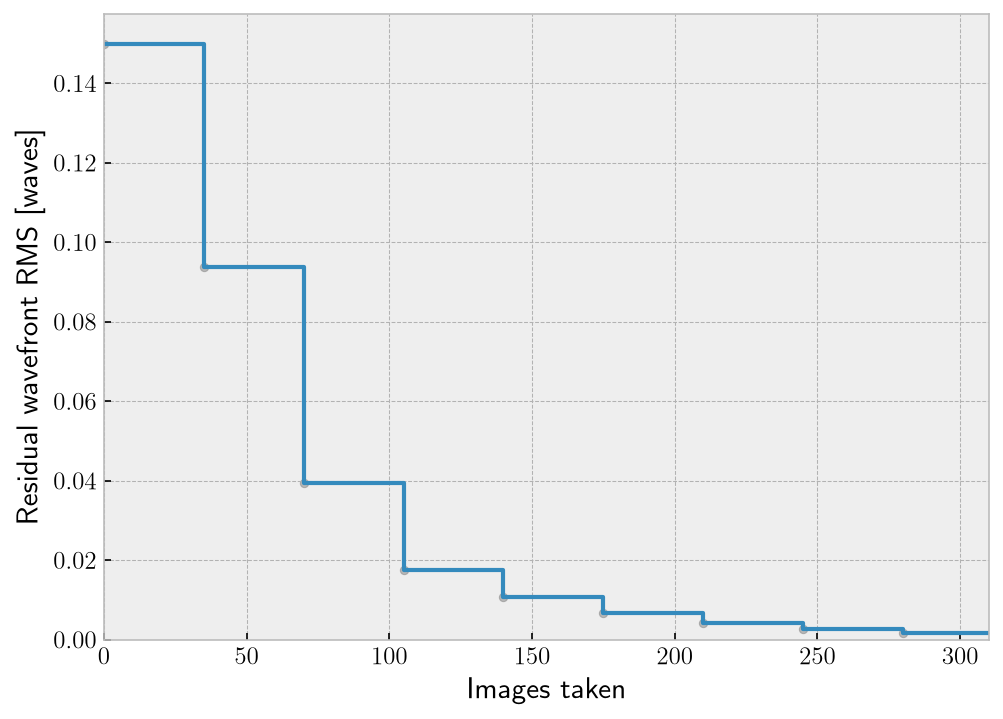

In [7]:
fig, ax = plt.subplots(dpi=150)
mean_rms = booth_rms_by_images.mean(axis=0)
std_rms = booth_rms_by_images.std(axis=0)
line, = ax.step(booth_image_grid, mean_rms, where="post")
ax.fill_between(
    booth_image_grid, np.maximum(0, mean_rms - std_rms), mean_rms + std_rms,
    step="post", color=line.get_color(), alpha=0.2,
)
booth_update_images = np.array([point["images_taken"] for point in booth_histories[0]])
ax.scatter(booth_update_images, mean_rms[booth_update_images], s=16, c="gray", alpha=0.5)
ax.set_xlabel("Images taken")
ax.set_ylabel("Residual wavefront RMS [waves]")
ax.set_xlim(0, IMAGE_BUDGET)
ax.set_ylim(bottom=0)
fig.savefig("booth_rms_vs_images.png", bbox_inches="tight")
plt.show()


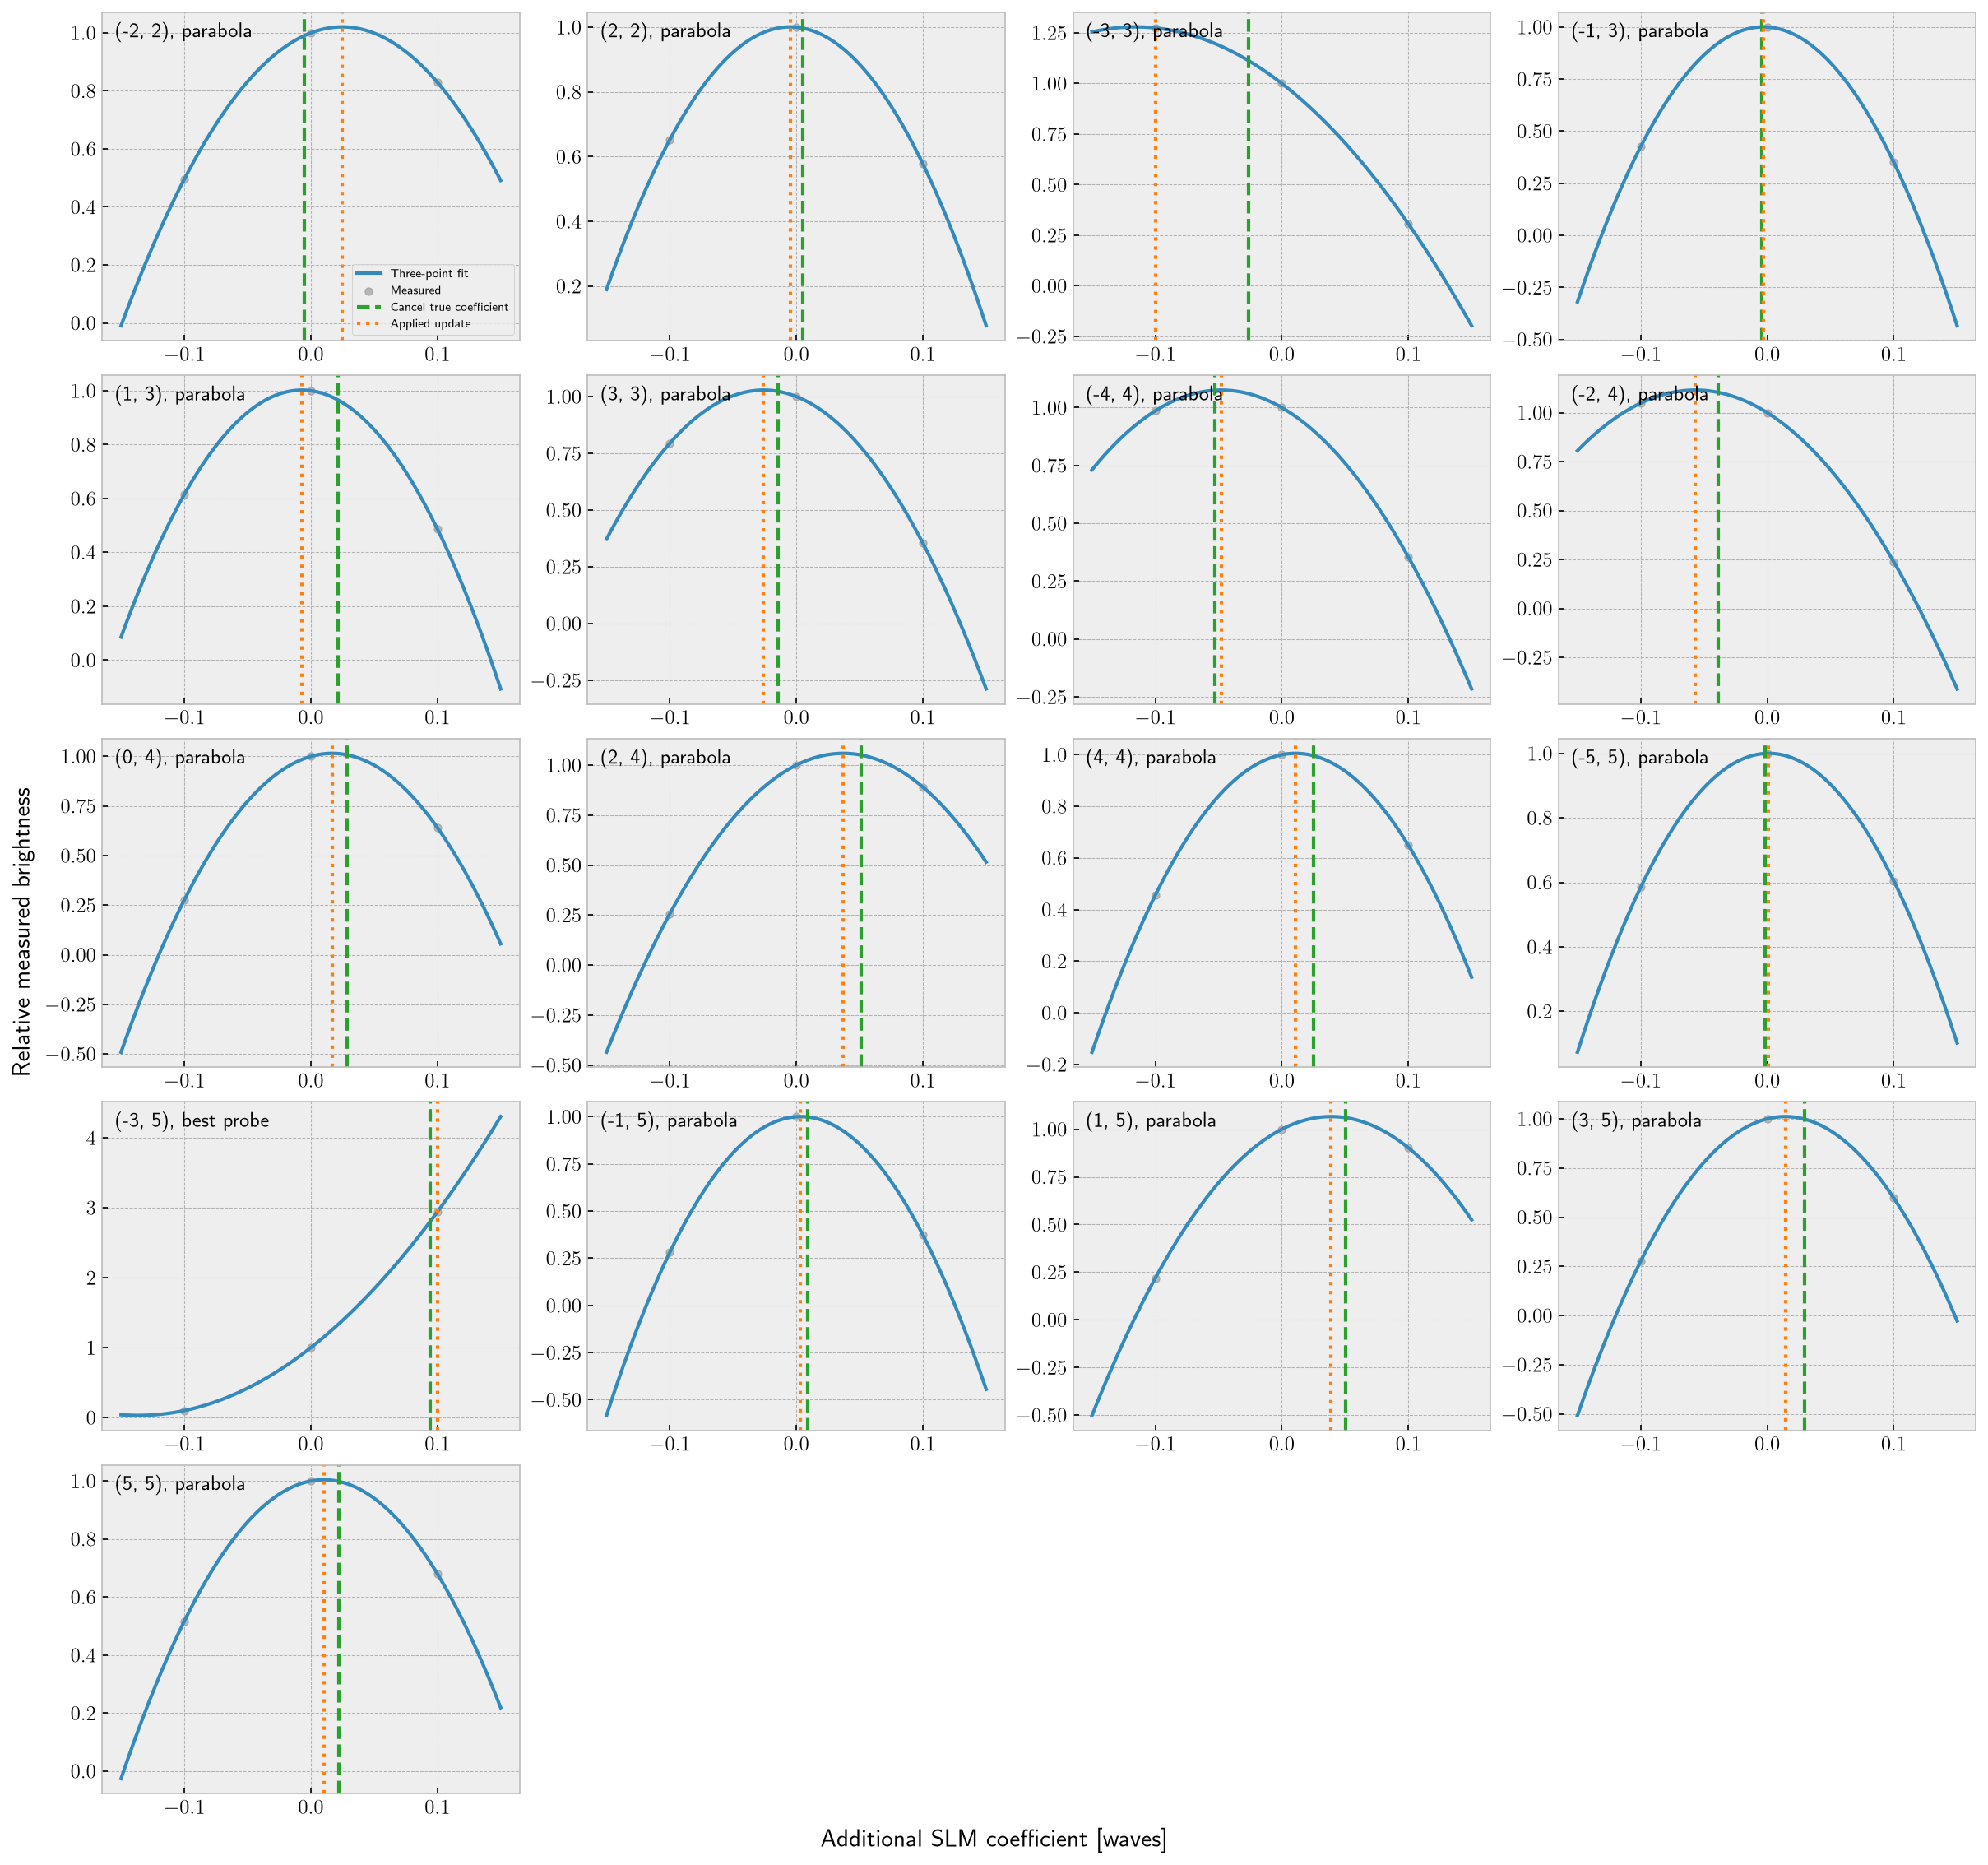

In [8]:
if not 0 <= DIAGNOSTIC_TRIAL < len(booth_histories):
    raise ValueError("DIAGNOSTIC_TRIAL must identify an existing trial.")
booth_diagnostic_history = booth_histories[DIAGNOSTIC_TRIAL]
if not 1 <= DIAGNOSTIC_SWEEP < len(booth_diagnostic_history):
    raise ValueError("DIAGNOSTIC_SWEEP must identify a completed sweep; increase IMAGE_BUDGET if needed.")
booth_before = booth_diagnostic_history[DIAGNOSTIC_SWEEP - 1]
booth_after = booth_diagnostic_history[DIAGNOSTIC_SWEEP]
booth_truth = booth_truths[DIAGNOSTIC_TRIAL]
booth_truth_coefficients = {tuple(mode): value for mode, value in zip(booth_truth.modes, booth_truth.strengths)}
booth_cancel_bias = -np.array([
    booth_truth_coefficients.get(tuple(mode), 0.0) + booth_before["slm_strengths"][i]
    for i, mode in enumerate(CORRECTION_MODES)
])

booth_ncols = min(4, len(CORRECTION_MODES))
booth_nrows = (len(CORRECTION_MODES) + booth_ncols - 1) // booth_ncols
fig, axs = plt.subplots(
    booth_nrows, booth_ncols, figsize=(4 * booth_ncols, 3 * booth_nrows),
    dpi=150, squeeze=False, layout="constrained",
)
probe_biases = np.array([-BOOTH_BIAS, 0.0, BOOTH_BIAS])
for i, (mode, ax) in enumerate(zip(CORRECTION_MODES, axs.flat)):
    measurements = booth_after["probe_metrics"][i]
    # Normalize for display only; the algorithm used raw measured brightness.
    brightness_scale = measurements[1] if measurements[1] > 0 else max(measurements.max(), 1.0)
    values = measurements / brightness_scale
    quadratic = (values[0] + values[2] - 2 * values[1]) / (2 * BOOTH_BIAS**2)
    linear = (values[2] - values[0]) / (2 * BOOTH_BIAS)
    plot_extent = max(1.5 * BOOTH_BIAS, 1.1 * abs(booth_cancel_bias[i]), 1.1 * abs(booth_after["update"][i]))
    plot_biases = np.linspace(-plot_extent, plot_extent, 200)
    ax.plot(plot_biases, quadratic * plot_biases**2 + linear * plot_biases + values[1], label="Three-point fit")
    ax.scatter(probe_biases, values, s=20, c="gray", alpha=0.5, label="Measured")
    ax.axvline(booth_cancel_bias[i], color="tab:green", linestyle="--", label="Cancel true coefficient")
    ax.axvline(booth_after["update"][i], color="tab:orange", linestyle=":", label="Applied update")
    fit_kind = "parabola" if booth_after["used_parabola"][i] else "best probe"
    ax.text(0.03, 0.97, f"({mode[0]}, {mode[1]}), {fit_kind}", transform=ax.transAxes, va="top")
axs.flat[0].legend(fontsize=7)
for ax in axs.flat[len(CORRECTION_MODES):]:
    fig.delaxes(ax)
fig.supxlabel("Additional SLM coefficient [waves]")
fig.supylabel("Relative measured brightness")
fig.savefig("booth_probe_fits.png", bbox_inches="tight")
plt.show()


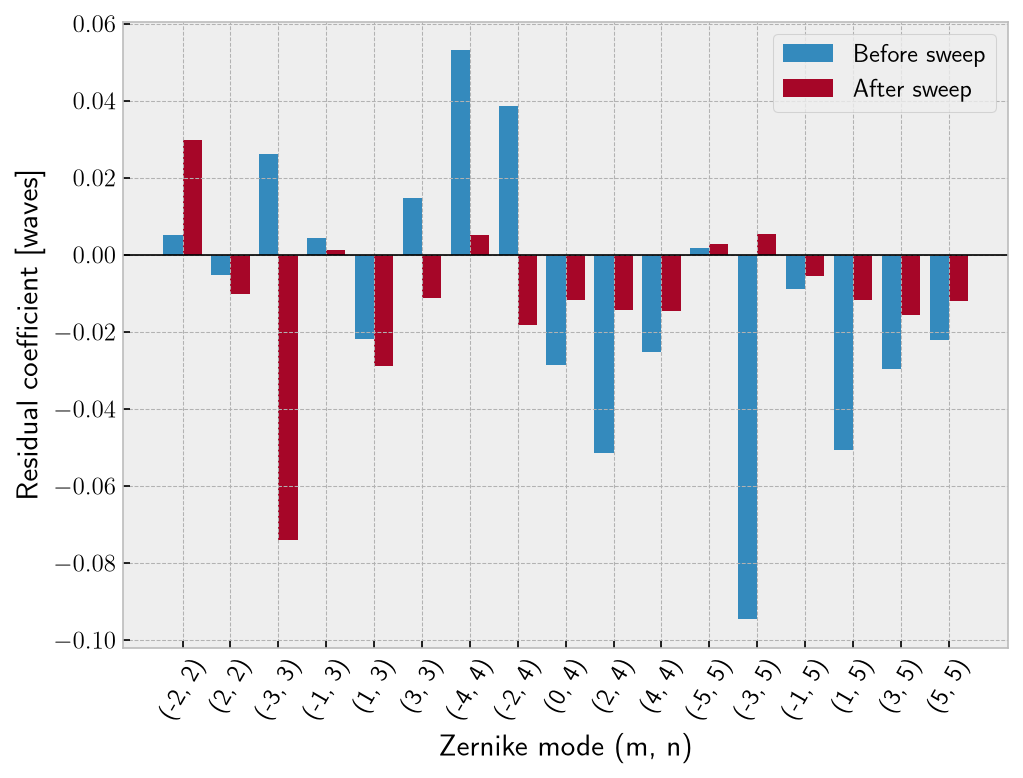

In [9]:
# Compare actual residual coefficients before and after the selected sweep.
coefficient_modes = list(dict.fromkeys(tuple(mode) for mode in list(booth_truth.modes) + CORRECTION_MODES))
slm_before = dict(zip(map(tuple, CORRECTION_MODES), booth_before["slm_strengths"]))
slm_after = dict(zip(map(tuple, CORRECTION_MODES), booth_after["slm_strengths"]))
residual_before = np.array([booth_truth_coefficients.get(mode, 0.0) + slm_before.get(mode, 0.0) for mode in coefficient_modes])
residual_after = np.array([booth_truth_coefficients.get(mode, 0.0) + slm_after.get(mode, 0.0) for mode in coefficient_modes])
mode_positions = np.arange(len(coefficient_modes))
fig, ax = plt.subplots(dpi=150)
ax.bar(mode_positions - 0.2, residual_before, width=0.4, label="Before sweep")
ax.bar(mode_positions + 0.2, residual_after, width=0.4, label="After sweep")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(mode_positions, labels=[f"({m}, {n})" for m, n in coefficient_modes], rotation=60)
ax.set_xlabel("Zernike mode (m, n)")
ax.set_ylabel("Residual coefficient [waves]")
ax.legend()
fig.savefig("booth_residual_coefficients.png", bbox_inches="tight")
plt.show()


In [10]:
np.savez_compressed(
    "booth_results.npz",
    images_taken=booth_image_grid, residual_rms=booth_rms_by_images,
    truth_modes=np.asarray(modes), correction_modes=np.asarray(CORRECTION_MODES),
    truth_strengths=np.array([truth.strengths for truth in booth_truths]),
    exposures=np.asarray(booth_exposures),
    update_images=np.array([[p["images_taken"] for p in h] for h in booth_histories]),
    slm_strengths=np.array([[p["slm_strengths"] for p in h] for h in booth_histories]),
    detected_photons=np.array([[p["photons_detected"] for p in h] for h in booth_histories]),
    probe_metrics=np.array([[p["probe_metrics"] for p in h[1:]] for h in booth_histories]),
    updates=np.array([[p["update"] for p in h[1:]] for h in booth_histories]),
    used_parabola=np.array([[p["used_parabola"] for p in h[1:]] for h in booth_histories]),
    initial_reference_snr=INITIAL_REFERENCE_SNR, aberration_rms=ABERRATION_RMS,
    image_budget=IMAGE_BUDGET, focal_positions=BOOTH_FOCAL_POSITIONS,
    bias=BOOTH_BIAS, correction_gain=CORRECTION_GAIN, max_modal_update=MAX_MODAL_UPDATE,
)
